# Does EarthCARE see snow when Aasiaat sees snow?

First comparison between the EO subset (EarthCARE ACM-CAP; Mason et al.
2023) and the ground truth: **detection coincidence only** — no amounts yet. For every overpass within 100 km of
**DMI 422000 Aasiaat** (the only station in the region with a precipitation
gauge) we ask whether the satellite and the gauge agree that it was snowing.

**Matching conventions** (following Kodamana & Fletcher 2021 and the CloudSat
point-validation literature):
- *Satellite*: profiles ≤ 100 km of the station, `convergence_status == 0`,
  snowfall taken at the **1000 m AGL reference level**, rates ≥ 20 mm/h
  screened as unphysical. A profile is "snowing" above **0.01 mm/h w.e.**
  One of the per-overpass summaries is an **IDW (inverse-distance-weighted)
  mean**: the profile rates averaged with weight 1/distance, so profiles near
  the station dominate and profiles 100 km out barely count — the weighting
  Kodamana & Fletcher (2021) found keeps satellite-vs-station skill stable
  out to ~70 km, where an unweighted mean degrades much sooner.
- *Station*: the hourly value at stamp *T* covers (*T*−1h, *T*]; matched
  stamps are those whose interval overlaps **overpass ± 30 min** (typically
  two stamps); a ±90 min sensitivity check is reported alongside.
  "Snowing" = matched **snow-phase** precipitation > 0, where hourly precip
  (`601`) counts as snow only in hours with air temperature ≤ **+1.5 °C** —
  the same phase proxy used in the DMI and cross-source consistency
  notebooks. The gauge reports liquid-equivalent totals regardless of phase,
  so without this crossing a late-May rain shower would count as a satellite
  "miss". Warm-phase precip excluded by the proxy is reported per window.

**Three caveats to keep in view:**
1. The satellite rate at 1 km AGL is an *extrapolation to the surface* across
   the radar's ~700 m blind zone.
2. The gauge reports in **0.1 mm steps once per hour** and Arctic gauges
   undercatch wind-blown snow (Kochendorfer et al. 2017) — light snowfall
   (≲0.1 mm/h) is largely invisible to it.
3. The satellite samples a ~200 km *line* for ~30 s; the gauge samples a
   *point* continuously. Snow on the track 80 km from town is a satellite
   "yes" and a gauge "no" without either being wrong — which is why every
   result below is stratified by distance.

## 1 · Load both sides and build the overpass table

One row per overpass (granule with profiles ≤ 100 km): what the satellite saw
at the reference level, and what the station reported in the matched hours.

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm

sys.path.insert(0, "../src")
import eo_reader as eo
from gauges import load_gauge_snow, snow_window_stats
from study_config import (OUTLIER_MMHR, SNOW_PHASE_MAX_TEMP_C,
                          SNOW_THRESHOLD_MMHR, STATIONS, THETA_FSS, WIND_FLOOR_MS)
from validation import advective_window, contingency, fss_pairs, fss_score

AASIAAT = STATIONS["aasiaat"]
STATION_ID = AASIAAT["dmi_id"]

# --- load both sides: the Disko-box EO subset and the cleaned hourly gauge ---
subset = eo.open_subset("../data/eo_subset/")
station, precip_snow = load_gauge_snow(AASIAAT)
# the all-phase series too: its difference from the snow series is rain
precip_all = station["601"].clip(lower=0)

# --- satellite side: per-profile arrays and the usability screen ---
profile_time = pd.to_datetime(subset["time"].values)
profile_granule = subset["granule"].values
is_converged = subset["convergence_status"].values == 0
snowfall_1km = subset["snowfall_mmhr_1000m"].values
dist_station = subset[f"distance_km_{STATION_ID}"].values

usable = (is_converged & np.isfinite(snowfall_1km)
          & (snowfall_1km < OUTLIER_MMHR))


def station_precip_in_window(overpass_time, half_window="30min"):
    """Gauge totals in the overpass window: (snow-phase sum, all-phase sum)
    in mm -- the difference is warm-phase (rain) precip. Both read through
    the shared covering-interval logic in src/gauges.py."""
    half = pd.Timedelta(half_window)
    return (snow_window_stats(station, precip_snow, overpass_time, half)[0],
            snow_window_stats(station, precip_all, overpass_time, half)[0])


# --- one row per overpass (granule) with usable profiles <= 100 km ---
overpass_rows = []
for granule_id in sorted(set(profile_granule[dist_station <= 100])):
    in_pass = (profile_granule == granule_id) & (dist_station <= 100) & usable
    if not in_pass.any():
        continue
    t_overpass = pd.Series(profile_time[in_pass]).mean().round("min")
    pass_distances = dist_station[in_pass]
    pass_rates = snowfall_1km[in_pass]
    # inverse-distance-weighted mean rate: near profiles count more
    idw_rate_mmhr = np.average(pass_rates, weights=1.0 / np.maximum(pass_distances, 1.0))
    snow30, all30 = station_precip_in_window(t_overpass, "30min")
    snow90, all90 = station_precip_in_window(t_overpass, "90min")
    overpass_hour = t_overpass.floor("h")
    overpass_rows.append({
        "granule": granule_id,
        "time": t_overpass,
        "closest_km": round(float(pass_distances.min()), 1),
        "n_profiles": int(in_pass.sum()),
        "sat_frac_snowing_100km": float((pass_rates > SNOW_THRESHOLD_MMHR).mean()),
        "sat_any_50km": (bool((pass_rates[pass_distances <= 50] > SNOW_THRESHOLD_MMHR).any())
                         if (pass_distances <= 50).any() else False),
        "sat_any_30km": (bool((pass_rates[pass_distances <= 30] > SNOW_THRESHOLD_MMHR).any())
                         if (pass_distances <= 30).any() else False),
        "sat_idw_mmhr": float(idw_rate_mmhr),
        "sat_max_mmhr": float(pass_rates.max()),
        "stn_snow_pm30_mm": snow30,
        "stn_snow_pm90_mm": snow90,
        "stn_rain_pm30_mm": all30 - snow30,
        "stn_temp_C": float(station["101"].get(overpass_hour, np.nan)),
        "stn_cloud_pct": float(station["801"].get(overpass_hour, np.nan)),
    })

# --- the overpass table and a first head-count of who saw snow ---
overpasses = pd.DataFrame(overpass_rows).sort_values("time").reset_index(drop=True)
print(f"{len(overpasses)} overpasses within 100 km of Aasiaat "
      f"({overpasses['time'].min():%Y-%m-%d} .. {overpasses['time'].max():%Y-%m-%d})")
print(f"satellite snowing (any profile <=100 km): "
      f"{int((overpasses.sat_frac_snowing_100km > 0).sum())}")
print(f"station SNOW-phase precip > 0, +/-30 min: "
      f"{int((overpasses.stn_snow_pm30_mm > 0).sum())}")
n_warm_windows = int((overpasses.stn_rain_pm30_mm > 0).sum())
print(f"windows with warm-phase (T > {SNOW_PHASE_MAX_TEMP_C} degC) precip "
      f"excluded by the phase proxy: {n_warm_windows}")
pd.set_option("display.width", 200)
overpasses

118 overpasses within 100 km of Aasiaat (2025-01-01 .. 2025-12-31)
satellite snowing (any profile <=100 km): 58
station SNOW-phase precip > 0, +/-30 min: 22
windows with warm-phase (T > 1.5 degC) precip excluded by the phase proxy: 4


,granule,time,closest_km,n_profiles,sat_frac_snowing_100km,sat_any_50km,sat_any_30km,sat_idw_mmhr,sat_max_mmhr,stn_snow_pm30_mm,stn_snow_pm90_mm,stn_rain_pm30_mm,stn_temp_C,stn_cloud_pct
0,03389C,2025-01-01 18:39:00,47.5,170,0.000000,False,False,0.000000,0.000000,0.0,0.0,0.0,-11.9,90.0
1,03411C,2025-01-03 04:24:00,60.4,153,0.379085,False,False,0.021155,0.330062,0.1,0.3,0.0,-2.2,100.0
2,03442C,2025-01-05 04:13:00,43.4,170,0.000000,False,False,0.000000,0.000000,0.0,0.0,0.0,-5.8,90.0
3,03498C,2025-01-08 18:46:00,22.0,186,0.693548,True,True,0.064468,0.763357,0.1,0.1,0.0,-5.1,90.0
4,03529C,2025-01-10 18:35:00,84.6,7,0.000000,False,False,0.000000,0.000000,0.0,0.0,0.0,-11.3,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,08944C,2025-12-24 18:43:00,20.1,89,0.000000,False,False,0.000000,0.000000,0.0,0.0,0.0,-11.5,0.0
114,08975C,2025-12-26 18:32:00,85.0,102,0.000000,False,False,0.000000,0.000000,0.0,0.0,0.0,-7.4,0.0
115,08997C,2025-12-28 04:18:00,31.7,180,0.138889,True,False,0.004101,0.182977,0.0,0.0,0.0,-6.3,100.0
116,09028C,2025-12-30 04:06:00,74.6,86,0.255814,False,False,0.273794,5.874022,0.0,0.0,1.1,3.3,100.0


## 2 · Case studies: the two strongest close passes

**04805C** (2025-04-02 18:39 UTC, closest 15 km) and **04858C**
(2025-04-06 04:14 UTC, closest 7.6 km) both carry ~3 mm/h snowfall on the
track. Each figure reads top to bottom: what the radar measured, what the
retrieval made of it, where the snow sat relative to the town, and what the
gauge did around the overpass minute.

C:\Users\marti\AppData\Local\Temp\ipykernel_11292\3258463613.py:36: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = axes[0].pcolormesh(along_x_2d, height_km, reflectivity, cmap="viridis",
C:\Users\marti\AppData\Local\Temp\ipykernel_11292\3258463613.py:43: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = axes[1].pcolormesh(along_x_2d, height_km, snow_curtain, cmap="magma_r",


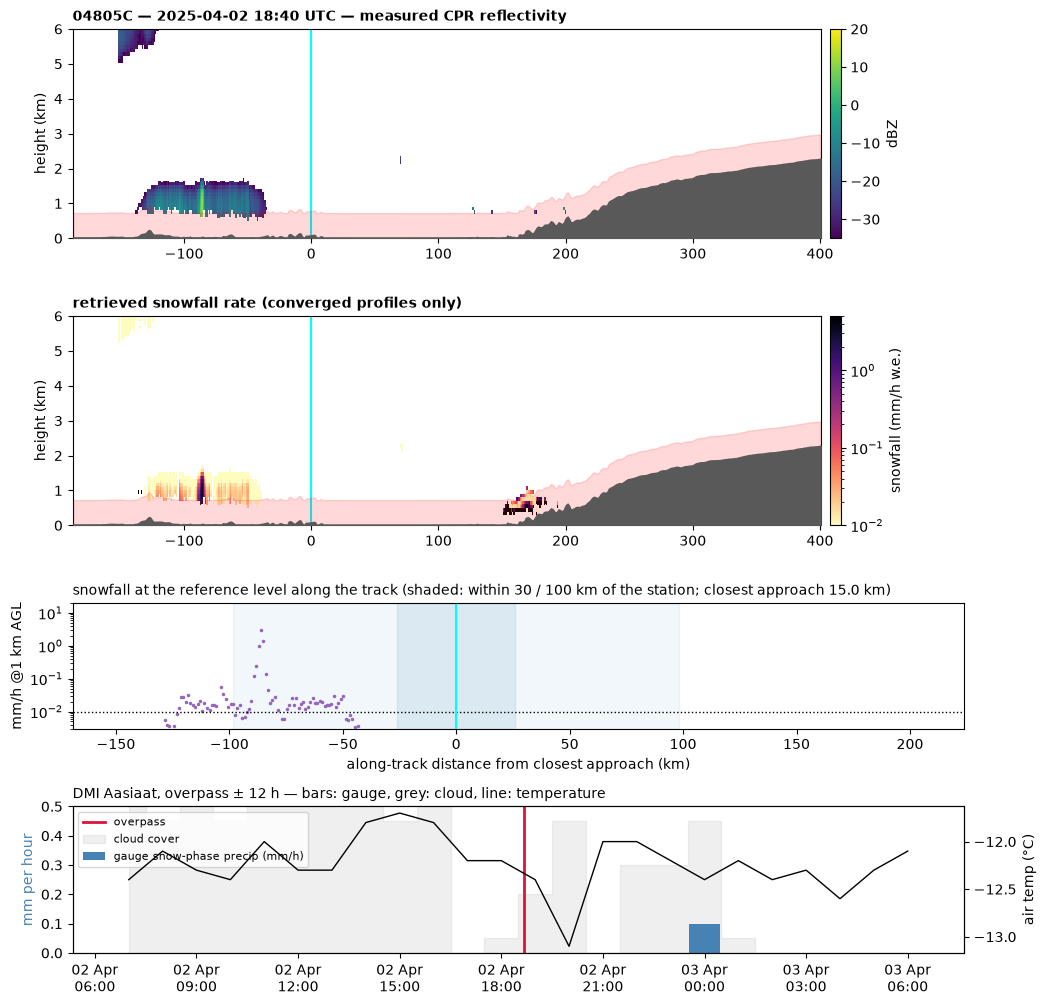

04805C: closest 15.0 km | snowing profiles <=30 km: 0/17 | max rate <=30 km: 0.00 mm/h | gauge snow-phase +/-30 min: 0.0 mm


In [2]:
def case_study(granule_id, save=True):
    """Four-panel figure for one granule: CPR reflectivity curtain, retrieved
    snowfall curtain, the 1 km AGL rate along the track, and the gauge
    +/-12 h around the overpass. Prints a one-line summary underneath."""
    # --- profiles of this granule, ordered south to north along the track ---
    in_granule = profile_granule == granule_id
    track = subset.isel(profile=np.where(in_granule)[0])
    track = track.isel(profile=np.argsort(track["latitude"].values))

    # x-axis: cumulative along-track distance, zeroed at the closest-approach
    # profile -- so the cyan closest-approach line sits exactly at x = 0
    track_distance_km = track[f"distance_km_{STATION_ID}"].values
    closest_idx = int(np.argmin(track_distance_km))
    lat_p, lon_p = track["latitude"].values, track["longitude"].values
    step_km = eo.great_circle_km(lat_p[:-1], lon_p[:-1], lat_p[1:], lon_p[1:])
    along_x = np.concatenate([[0.0], np.cumsum(step_km)])
    along_x -= along_x[closest_idx]

    # --- curtain fields (converged profiles only for the retrieval) ---
    converged = track["convergence_status"].values == 0
    height_km = track["height"].values / 1000.0
    along_x_2d = np.repeat(along_x[:, None], height_km.shape[1], axis=1)
    reflectivity = track["CPR_reflectivity_factor"].values
    snow_curtain = track["ice_mass_flux"].values * 3600.0
    snow_curtain = np.where(converged[:, None] & (snow_curtain > 1e-3),
                            snow_curtain, np.nan)
    rate_1km = np.where(converged, track["snowfall_mmhr_1000m"].values, np.nan)
    elev_km = track["elevation"].values / 1000.0
    t_overpass = pd.Series(pd.to_datetime(track["time"].values)).mean().round("min")

    fig, axes = plt.subplots(4, 1, figsize=(11.5, 12),
                             gridspec_kw={"height_ratios": [2, 2, 1.2, 1.4],
                                          "hspace": 0.45})

    # --- panel 1: measured reflectivity; panel 2: retrieved snowfall ---
    mesh = axes[0].pcolormesh(along_x_2d, height_km, reflectivity, cmap="viridis",
                              vmin=-35, vmax=20, shading="nearest")
    plt.colorbar(mesh, ax=axes[0], pad=0.01, label="dBZ")
    axes[0].set_title(f"{granule_id} — {t_overpass:%Y-%m-%d %H:%M} UTC — "
                      "measured CPR reflectivity", loc="left",
                      fontsize=10, fontweight="bold")

    mesh = axes[1].pcolormesh(along_x_2d, height_km, snow_curtain, cmap="magma_r",
                              norm=LogNorm(vmin=1e-2, vmax=5),
                              shading="nearest")
    plt.colorbar(mesh, ax=axes[1], pad=0.01, label="snowfall (mm/h w.e.)")
    axes[1].set_title("retrieved snowfall rate (converged profiles only)",
                      loc="left", fontsize=10, fontweight="bold")
    # terrain (grey), the ~700 m clutter blind zone (red), closest approach (cyan)
    for ax in axes[:2]:
        ax.set_ylim(0, 6)
        ax.set_ylabel("height (km)")
        ax.fill_between(along_x, 0, elev_km, color="0.35", zorder=5)
        ax.fill_between(along_x, elev_km, elev_km + 0.7, color="red",
                        alpha=0.15, zorder=4)
        ax.axvline(0, color="cyan", lw=1.5)

    # --- panel 3: the reference-level rate along the track ---
    axes[2].plot(along_x, rate_1km, ".", ms=3, color="tab:purple")
    axes[2].axhline(SNOW_THRESHOLD_MMHR, color="k", ls=":", lw=1)
    axes[2].axvline(0, color="cyan", lw=1.5)
    # shade the stretch of track that lies inside each station ring, from the
    # actual per-profile distances (not a fixed +/- span)
    for ring_km, alpha in [(100, 0.06), (30, 0.10)]:
        inside = track_distance_km <= ring_km
        if inside.any():
            axes[2].axvspan(along_x[inside].min(), along_x[inside].max(),
                            color="tab:blue", alpha=alpha)
    axes[2].set_yscale("log")
    axes[2].set_ylim(3e-3, 20)
    axes[2].set_ylabel("mm/h @1 km AGL")
    axes[2].set_xlabel("along-track distance from closest approach (km)")
    axes[2].set_title("snowfall at the reference level along the track "
                      "(shaded: within 30 / 100 km of the station; "
                      f"closest approach {track_distance_km.min():.1f} km)",
                      loc="left", fontsize=10)

    # --- panel 4: the gauge +/-12 h -- snow-phase bars, cloud shading, temp ---
    station_window = station.loc[t_overpass - pd.Timedelta("12h"):
                                 t_overpass + pd.Timedelta("12h")]
    ax_gauge = axes[3]
    gauge_snow_window = precip_snow.loc[station_window.index]
    ax_gauge.bar(station_window.index, gauge_snow_window.fillna(0), width=1/26,
                 color="steelblue", label="gauge snow-phase precip (mm/h)")
    ax_gauge.axvline(t_overpass, color="crimson", lw=2, label="overpass")
    ax_gauge.set_ylabel("mm per hour", color="steelblue")
    ax_gauge.set_ylim(0, max(0.5, float(gauge_snow_window.max()) * 1.4))
    ax_temp = ax_gauge.twinx()
    ax_temp.plot(station_window.index, station_window["101"], color="k", lw=1,
                 label="temp")
    ax_temp.set_ylabel("air temp (°C)")
    cloud_fraction = station_window["801"].fillna(0) / 100.0
    ax_gauge.fill_between(station_window.index, 0,
                          ax_gauge.get_ylim()[1] * cloud_fraction, step="mid",
                          color="0.6", alpha=0.15, zorder=0, label="cloud cover")
    ax_gauge.legend(loc="upper left", fontsize=8)
    ax_gauge.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
    ax_gauge.set_title("DMI Aasiaat, overpass ± 12 h — bars: gauge, grey: cloud, "
                       "line: temperature", loc="left", fontsize=10)

    if save:
        fig.savefig(f"../figures/eo_dmi_case_{granule_id}.png", dpi=300,
                    bbox_inches="tight")
    plt.show()

    # --- one-line summary: what the two sides saw near the station ---
    within_30km = (track_distance_km <= 30) & converged
    print(f"{granule_id}: closest {track_distance_km.min():.1f} km | "
          f"snowing profiles <=30 km: "
          f"{int((rate_1km[within_30km] > SNOW_THRESHOLD_MMHR).sum())}/{int(within_30km.sum())} | "
          f"max rate <=30 km: {np.nanmax(rate_1km[within_30km]) if within_30km.any() else float('nan'):.2f} mm/h | "
          f"gauge snow-phase +/-30 min: "
          f"{station_precip_in_window(t_overpass)[0]:.1f} mm")

case_study("04805C")

**04805C, read:** the reflectivity shows where the cloud actually was
along the track, the third panel shows whether any of its snow fell inside
the 30 km ring, and the bottom panel shows the gauge's day. The station
reported clearing skies and 0.0 mm at the overpass hour — so if the snowing
profiles sit well away from the ring, this is a *geometry* mismatch, not a
detection failure.

C:\Users\marti\AppData\Local\Temp\ipykernel_11292\3258463613.py:36: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = axes[0].pcolormesh(along_x_2d, height_km, reflectivity, cmap="viridis",
C:\Users\marti\AppData\Local\Temp\ipykernel_11292\3258463613.py:43: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = axes[1].pcolormesh(along_x_2d, height_km, snow_curtain, cmap="magma_r",


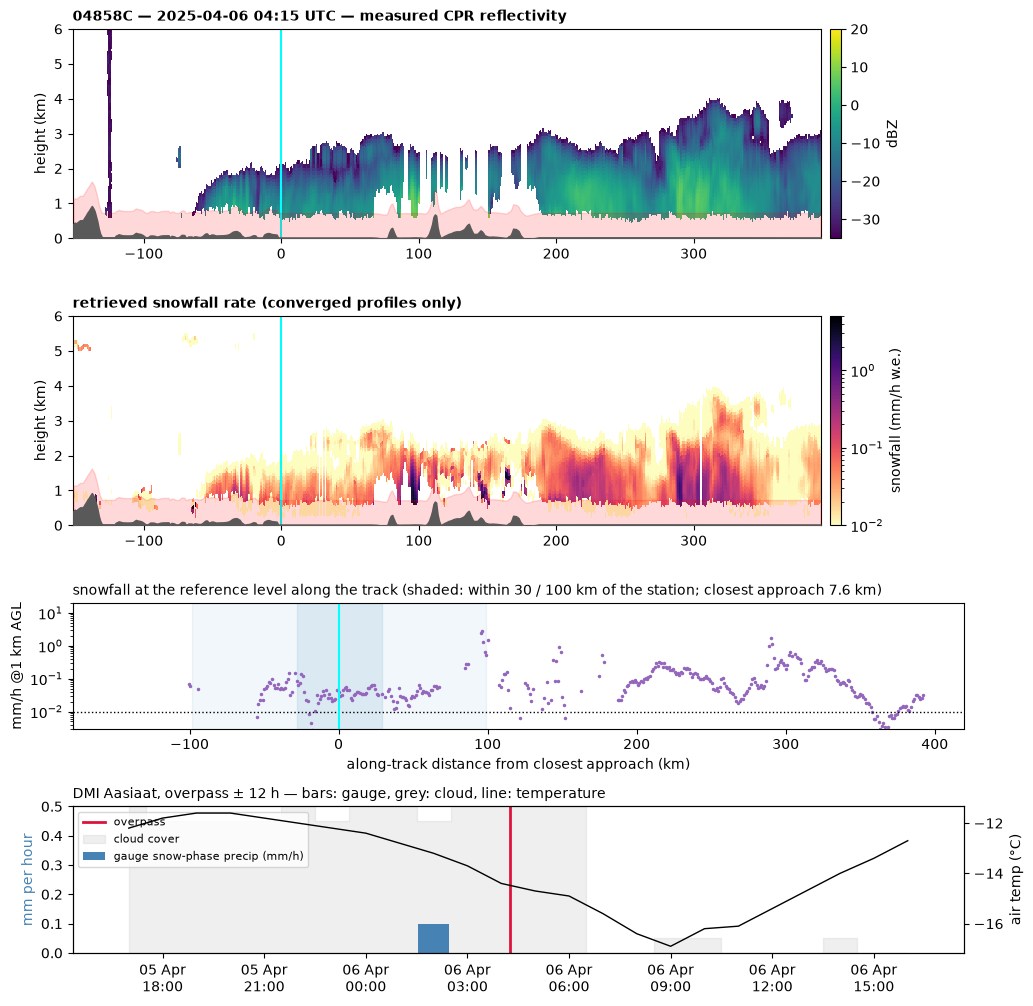

04858C: closest 7.6 km | snowing profiles <=30 km: 51/55 | max rate <=30 km: 0.14 mm/h | gauge snow-phase +/-30 min: 0.0 mm


In [3]:
case_study("04858C")

**04858C, read:** the strongest possible configuration — the track
crosses 7.6 km from the gauge under full overcast. The gauge logged 0.1 mm
two hours before the overpass and zeros around it: light snowfall hovering at
the gauge's resolution floor. Whether the satellite's ~1 mm/h profiles near
the ring are "right" cannot be settled by this gauge — which is exactly the
kind of case the contingency table below has to count honestly.

## 3 · All overpasses: do they agree it is snowing?

Each overpass lands in one of four boxes, depending on what each side said:

| | **gauge: snow** (snow-phase precip > 0 in the matched window) | **gauge: dry** |
|---|---|---|
| **satellite: snow** | **hit** — both recorded snowfall | **false alarm** — satellite yes, gauge no |
| **satellite: dry** | **miss** — gauge yes, satellite no | **correct negative** — both dry |

("False alarm" and "miss" are the standard verification terms, taking the
gauge as reference — not a verdict on who is physically right: a satellite
"false alarm" can be real snow the gauge under-caught or snow that fell away
from town.)

The two scores condense the table:
- **POD** (probability of detection) = hit / (hit + miss) — *of the overpasses
  where the gauge saw snow, what fraction did the satellite also see?* 1.0 is
  perfect, 0 means the satellite missed every gauge event.
- **FAR** (false-alarm ratio) = false alarm / (hit + false alarm) — *of the
  overpasses where the satellite said snow, what fraction had a dry gauge?*
  0 is perfect; high FAR here mostly reflects the geometry and the gauge's
  0.1 mm floor rather than satellite error.

The satellite criteria differ in how they weigh distance:
- **any profile ≤ 100 km** — the loosest: one snowing profile anywhere in the
  collocation circle counts as satellite-yes;
- **any profile ≤ 50 km** — the middle ground, matching the radius Bennartz
  et al. (2019) used for CloudSat snowfall at Summit;
- **any profile ≤ 30 km** — only snow close enough that the gauge could
  plausibly have seen the same weather;
- **IDW mean > 0.01** — *inverse-distance weighting*: every profile's rate is
  averaged with weight 1/distance (a profile 10 km out counts ten times as
  much as one 100 km out), and the overpass is satellite-yes if that weighted
  mean clears the detection threshold. It behaves like "was it snowing *near*
  the station, on balance" rather than "was it snowing *anywhere*".

In [4]:
# contingency() comes from src/validation.py

# --- gauge reference: snow-phase precip > 0 in the +/-30 min (or +/-90 min) window ---
gauge_snowing_30min = overpasses["stn_snow_pm30_mm"] > 0
gauge_snowing_90min = overpasses["stn_snow_pm90_mm"] > 0

# --- the four satellite "it is snowing" criteria ---
satellite_criteria = {
    "sat: any profile <=100 km": overpasses["sat_frac_snowing_100km"] > 0,
    "sat: any profile <=50 km": overpasses["sat_any_50km"],
    "sat: any profile <=30 km": overpasses["sat_any_30km"],
    "sat: IDW mean > 0.01": overpasses["sat_idw_mmhr"] > SNOW_THRESHOLD_MMHR,
}

# --- contingency tables: primary +/-30 min window, then the +/-90 min sensitivity ---
contingency_30min = pd.DataFrame({name: contingency(sat_snowing, gauge_snowing_30min)
                                  for name, sat_snowing in satellite_criteria.items()}).T
print(f"station reference:\n SNOW-phase precip > 0 within +/-30 min  "
      f"({int(gauge_snowing_30min.sum())}/{len(overpasses)} overpasses)")
display(contingency_30min)
print(f"\nsensitivity, +/-90 min window "
      f"({int(gauge_snowing_90min.sum())}/{len(overpasses)} station-yes):")
display(pd.DataFrame({name: contingency(sat_snowing, gauge_snowing_90min)
                      for name, sat_snowing in satellite_criteria.items()}).T)

station reference:
 SNOW-phase precip > 0 within +/-30 min  (22/118 overpasses)


,hit,miss,false_alarm,correct_neg,POD,FAR
sat: any profile <=100 km,15.0,7.0,43.0,53.0,0.68,0.74
sat: any profile <=50 km,8.0,14.0,11.0,85.0,0.36,0.58
sat: any profile <=30 km,4.0,18.0,3.0,93.0,0.18,0.43
sat: IDW mean > 0.01,12.0,10.0,26.0,70.0,0.55,0.68



sensitivity, +/-90 min window (27/118 station-yes):


,hit,miss,false_alarm,correct_neg,POD,FAR
sat: any profile <=100 km,19.0,8.0,39.0,52.0,0.70,0.67
sat: any profile <=50 km,8.0,19.0,11.0,80.0,0.30,0.58
sat: any profile <=30 km,4.0,23.0,3.0,88.0,0.15,0.43
sat: IDW mean > 0.01,15.0,12.0,23.0,68.0,0.56,0.61


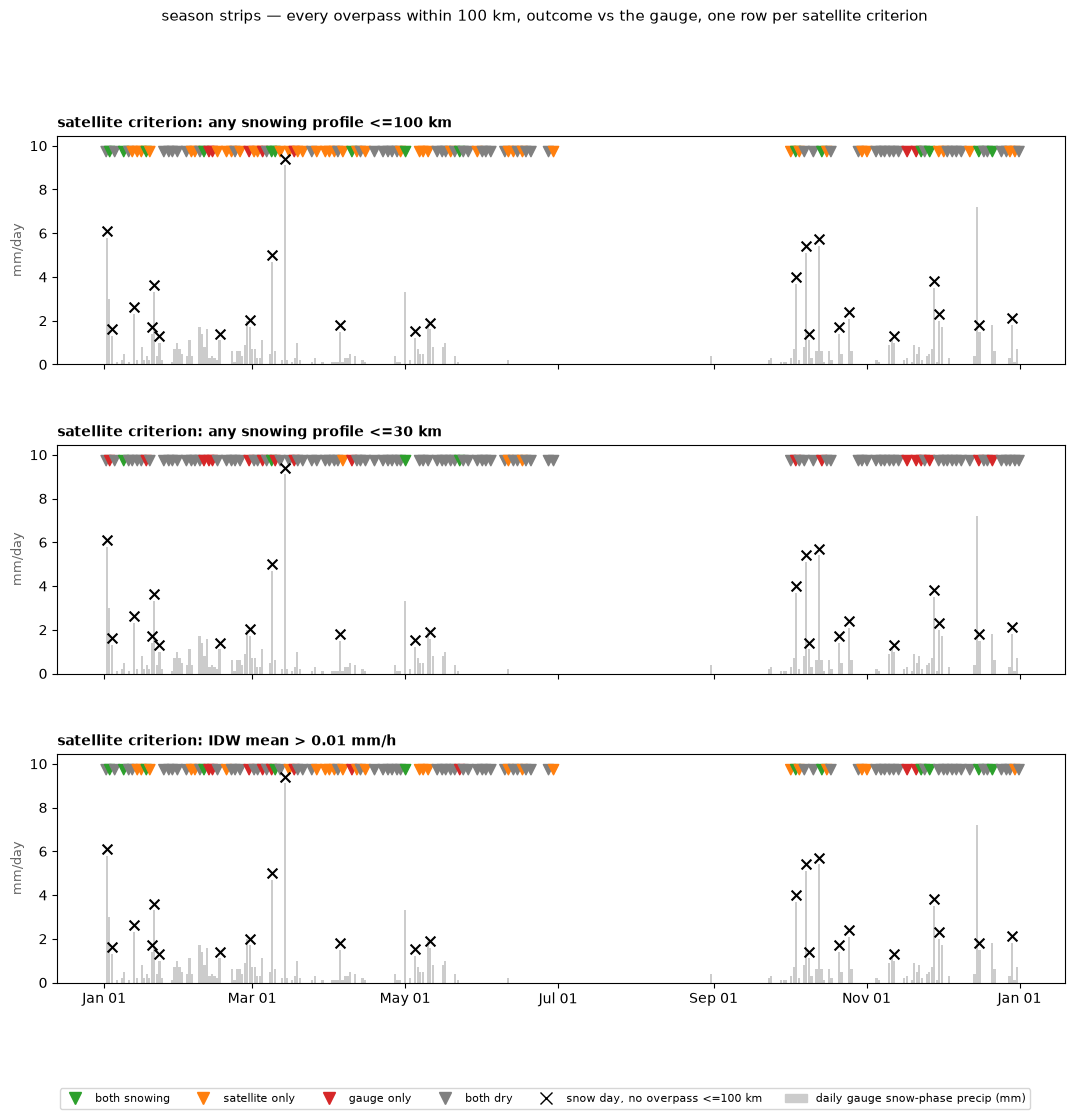

In [5]:
# --- daily gauge snow over the EO period: the station file covers the full
#     year, so clip it to the span the overpasses actually cover ---
period_start = overpasses["time"].min().floor("D") - pd.Timedelta("2D")
period_end = overpasses["time"].max().ceil("D") + pd.Timedelta("2D")
gauge_daily_snow_mm = precip_snow.loc[period_start:period_end].resample("D").sum()
strip_ymax = max(gauge_daily_snow_mm.max() * 1.15, 1)

# --- snow days the satellite never sampled: daily precip >= 1 mm but no
#     overpass within 100 km that day (e.g. Mar 14: 9.1 mm, closest track
#     110 km) -- these gaps are the overpass-limited reality, so mark them ---
overpass_days = set(overpasses["time"].dt.date)
unsampled_snow_days = gauge_daily_snow_mm[
    (gauge_daily_snow_mm >= 1.0)
    & ~pd.Series(gauge_daily_snow_mm.index.date,
                 index=gauge_daily_snow_mm.index).isin(overpass_days)]

# --- one strip per satellite criterion (the <=50 km row is kept for reference) ---
strip_criteria = [
    ("any snowing profile <=100 km", overpasses["sat_frac_snowing_100km"] > 0),
    # ("any snowing profile <=50 km", overpasses["sat_any_50km"]),
    ("any snowing profile <=30 km", overpasses["sat_any_30km"]),
    ("IDW mean > 0.01 mm/h", overpasses["sat_idw_mmhr"] > SNOW_THRESHOLD_MMHR),
]
gauge_snowing = gauge_snowing_30min.values

# --- plotting the season strips: daily gauge bars + one outcome marker per overpass ---
fig, axes = plt.subplots(len(strip_criteria), 1, figsize=(13, 11),
                         sharex=True, gridspec_kw={"hspace": 0.35})
for ax, (name, sat_flags) in zip(axes, strip_criteria):
    sat_snowing = np.asarray(sat_flags.values, dtype=bool)
    ax.bar(gauge_daily_snow_mm.index, gauge_daily_snow_mm.values, width=0.9,
           color="0.8")
    # hit = green, false alarm = orange, miss = red, correct negative = grey
    outcome_color = np.where(sat_snowing & gauge_snowing, "tab:green",
                    np.where(sat_snowing & ~gauge_snowing, "tab:orange",
                    np.where(~sat_snowing & gauge_snowing, "tab:red", "0.5")))
    ax.scatter(overpasses["time"], np.full(len(overpasses), strip_ymax * 0.93),
               c=outcome_color, s=55, marker="v", zorder=5)
    ax.scatter(unsampled_snow_days.index,
               unsampled_snow_days.values + strip_ymax * 0.03, marker="x",
               s=50, c="k", linewidth=1.5, zorder=6)
    ax.set_ylim(0, strip_ymax)
    ax.set_ylabel("mm/day", color="0.4", fontsize=9)
    ax.set_title(f"satellite criterion: {name}", loc="left", fontsize=10,
                 fontweight="bold")

# --- shared legend, title, save ---
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
legend_handles = (
    [plt.Line2D([], [], color=c, marker="v", ls="", ms=9, label=l)
     for c, l in [("tab:green", "both snowing"),
                  ("tab:orange", "satellite only"),
                  ("tab:red", "gauge only"), ("0.5", "both dry")]]
    + [plt.Line2D([], [], color="k", marker="x", ls="", ms=8,
                  label="snow day, no overpass <=100 km"),
       plt.Rectangle((0, 0), 1, 1, color="0.8",
                     label="daily gauge snow-phase precip (mm)")])
fig.legend(handles=legend_handles, loc="lower center", ncol=6, fontsize=8,
           bbox_to_anchor=(0.5, -0.01))
fig.suptitle("season strips — every overpass within 100 km, outcome vs the "
             "gauge, one row per satellite criterion", fontsize=11, y=0.995)
fig.savefig("../figures/eo_dmi_coincidence.png", dpi=130, bbox_inches="tight")
plt.show()

## 4 · Distance

Left: how often satellite and gauge agree, as a function of how close the
track came. Right: matched-hour gauge total vs the satellite's IDW rate —
points on the axes are the disagreements.

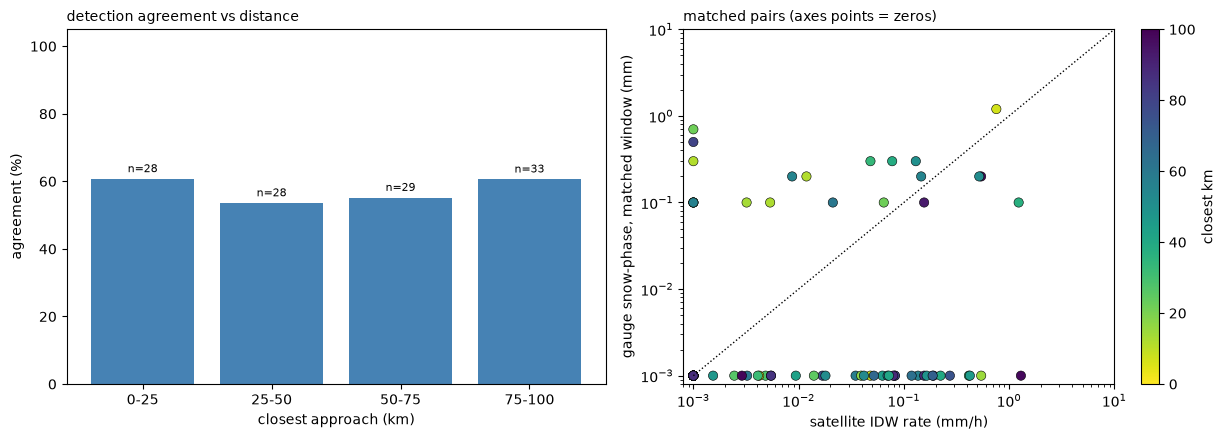

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

# --- left: agreement rate (<=100 km criterion vs gauge) binned by closest approach ---
distance_bins = [0, 25, 50, 75, 100]
bin_labels = [f"{a}-{b}" for a, b in zip(distance_bins[:-1], distance_bins[1:])]
agree_100km = ((overpasses["sat_frac_snowing_100km"] > 0) == gauge_snowing_30min)
distance_bin = pd.cut(overpasses["closest_km"], distance_bins, labels=bin_labels)
agreement_rate = agree_100km.groupby(distance_bin, observed=True).mean()
bin_count = agree_100km.groupby(distance_bin, observed=True).size()
axes[0].bar(agreement_rate.index.astype(str), agreement_rate.values * 100,
            color="steelblue")
for i, (frac, n) in enumerate(zip(agreement_rate.values, bin_count.values)):
    axes[0].text(i, frac * 100 + 2, f"n={n}", ha="center", fontsize=8)
axes[0].set_ylim(0, 105)
axes[0].set_xlabel("closest approach (km)")
axes[0].set_ylabel("agreement (%)")
axes[0].set_title("detection agreement vs distance", loc="left", fontsize=10)

# --- right: satellite IDW rate vs gauge amount, coloured by closest approach ---
sat_idw = overpasses["sat_idw_mmhr"].clip(lower=1e-3)      # zeros pushed to the axes
gauge_snow_mm = overpasses["stn_snow_pm30_mm"].clip(lower=1e-3)
axes[1].scatter(sat_idw, gauge_snow_mm, c=overpasses["closest_km"], cmap="viridis_r",
                vmin=0, vmax=100, s=45, edgecolor="k", linewidth=0.4)
axes[1].plot([1e-3, 10], [1e-3, 10], "k:", lw=1)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlim(8e-4, 10); axes[1].set_ylim(8e-4, 10)
axes[1].set_xlabel("satellite IDW rate (mm/h)")
axes[1].set_ylabel("gauge snow-phase, matched window (mm)")
colorbar = plt.colorbar(axes[1].collections[0], ax=axes[1], label="closest km")
axes[1].set_title("matched pairs (axes points = zeros)", loc="left",
                  fontsize=10)
plt.tight_layout()
plt.show()

## 5 · At what scale do they agree? — Fractions Skill Score

The contingency tables suffer from the **double-penalty problem**: 04805C is
scored a false alarm because its snow sat 30 km from town — punished once for
"snow where the gauge saw none" and implicitly again for missing the event
where it actually was. Neighbourhood verification was invented for exactly
this (Roberts & Lean 2008, the **Fractions Skill Score**): instead of
demanding agreement at a point, compare the *fraction* of samples exceeding a
threshold within neighbourhoods of increasing size, and find the scale at
which the two data sources start telling the same story.

**Adaptation to a nadir curtain vs a point gauge** (in the spirit of
Mittermaier's HiRA framework (2014), which verifies model neighbourhoods
against single stations): for each overpass *i*,

$$ p^{sat}_i(L,\theta) = \text{fraction of usable profiles} \le L\,
   \text{km snowing above } \theta, \qquad
   p^{gauge}_i(T) = \text{fraction of hourly stamps in } \pm T
   \text{ with snow-phase precip} $$

$$ \mathrm{FSS}(L,T,\theta) = 1 -
   \frac{\sum_i (p^{gauge}_i - p^{sat}_i)^2}
        {\sum_i (p^{gauge}_i)^2 + \sum_i (p^{sat}_i)^2} $$

1 = the fractions always agree; 0 = no overlap at all.

**The skill reference.** f₀ is the *base rate*: the mean gauge fraction over
all pairs — how often it is snowing at Aasiaat during an overpass window at
all (≈ 0.08–0.10 here, i.e. roughly one window in eleven). A random forecast
issued with that same frequency scores FSS ≈ f₀ on average, and a perfect one
scores 1, so **FSS_useful = 0.5 + f₀/2 is simply the halfway point between
random and perfect** (Roberts & Lean 2008). The smallest L where the curve
clears it is the *skillful scale* — below it, agreement is not demonstrably
better than a calibrated guess. It is a convention, not a significance test;
and because our pair population changes with L, f₀ drifts along the curve
(0.25 at L=10 down to 0.08 at L=100), so **FSS_useful is drawn per L** —
0.5 + f₀(L)/2, each point using its own base rate — rather than as one
horizontal line.

Two deliberate choices:
- **Threshold harmonized to the gauge:** the primary satellite threshold is
  **0.1 mm/h** — the gauge's physical resolution floor — so both binaries
  mean the same thing ("snow the gauge could in principle have seen"). The
  0.01 mm/h detection threshold used elsewhere is kept as a sensitivity
  curve.
- **Time window:** primary fixed ±1 h; a sensitivity curve couples the window
  to scale advectively, T = L / v (station 10-m wind at the overpass hour,
  floored at 2 m/s) — the same space-to-time logic Souverijns et al. (2018)
  and Lemonnier et al. (2019) used for MRR matching.

Two caveats for reading the curve:
- FSS is normally summed over thousands of windows; here N is the overpass
  count (in the table), so the curves should be read as indicative.
- Unlike textbook FSS, where the window slides over a *fixed* field and the
  score rises monotonically with scale, here **the pair population itself
  changes with L**: only overpasses with profiles inside L qualify, so small
  radii rest on a handful of close passes (n in the table). The left end of
  the curve (L ≤ 25 km) is a few-sample artifact, not evidence of
  small-scale skill — the interpretable regime starts where n stabilizes
  (L ≥ 50 km).

In [7]:
FSS_RADII_KM = list(range(10, 101, 10))   # neighbourhood radii L
THETA_PRIMARY = THETA_FSS      # harmonized to the gauge's resolution floor
THETA_SENSITIVITY = SNOW_THRESHOLD_MMHR

# fss_pairs / fss_score / advective_window come from src/validation.py; they
# need the site laid out as a dict (the stations notebook's native shape)
aasiaat_site = dict(
    profile_usable=usable, profile_granule=profile_granule,
    profile_distance_km=dist_station, profile_snowfall_mmhr=snowfall_1km,
    overpasses=overpasses, station_hourly=station, gauge_snow_mmhr=precip_snow)


def build_pairs(L_km, theta, advective=False):
    """One (p_sat, p_gauge) pair per overpass with usable profiles <= L_km:
    the shared fss_pairs with a fixed +/-1 h window, or +/-L/v driven by the
    station 10-m wind when advective."""
    half_window = (advective_window(station["301"], L_km)
                   if advective else pd.Timedelta("1h"))
    return fss_pairs(aasiaat_site, L_km, theta, half_window)


# --- FSS for every radius and the three (theta, window) curves ---
fss_rows = []
for L in FSS_RADII_KM:
    for label, theta, advective in [("theta=0.1, T=+/-1h", THETA_PRIMARY, False),
                                    ("theta=0.01, T=+/-1h", THETA_SENSITIVITY, False),
                                    ("theta=0.1, T=L/v", THETA_PRIMARY, True)]:
        pairs = build_pairs(L, theta, advective)
        fss_rows.append({"L_km": L, "curve": label, "n_pairs": len(pairs),
                         "f0_gauge": (round(float(pairs[:, 1].mean()), 3)
                                      if len(pairs) else np.nan),
                         "FSS": round(fss_score(pairs), 3)})
fss_table = pd.DataFrame(fss_rows)
fss_table

,L_km,curve,n_pairs,f0_gauge,FSS
0,10,"theta=0.1, T=+/-1h",8,0.167,0.947
1,10,"theta=0.01, T=+/-1h",8,0.167,0.643
2,10,"theta=0.1, T=L/v",8,0.188,0.889
3,20,"theta=0.1, T=+/-1h",20,0.133,0.562
4,20,"theta=0.01, T=+/-1h",20,0.133,0.460
5,20,"theta=0.1, T=L/v",20,0.146,0.528
6,30,"theta=0.1, T=+/-1h",32,0.115,0.458
7,30,"theta=0.01, T=+/-1h",32,0.115,0.365
8,30,"theta=0.1, T=L/v",32,0.115,0.513
9,40,"theta=0.1, T=+/-1h",40,0.158,0.455


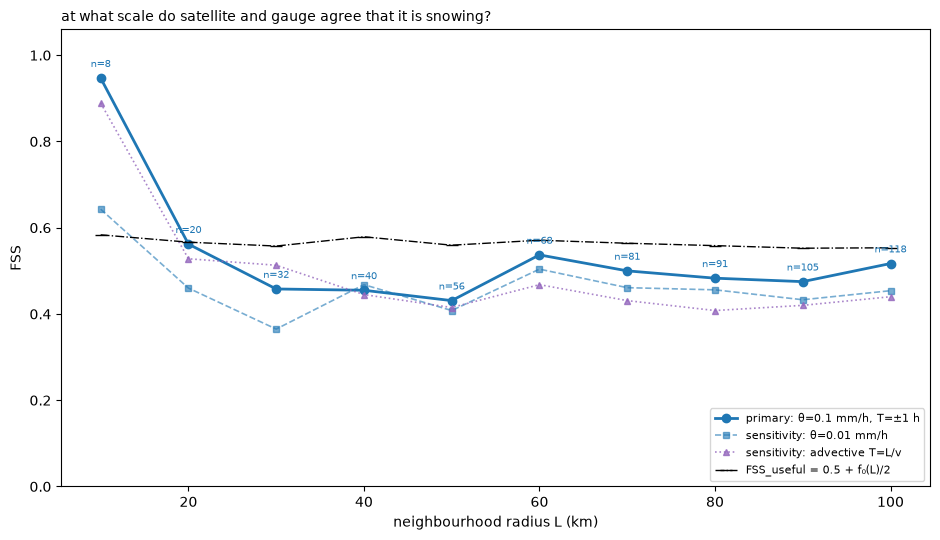

In [8]:
# --- plotting FSS vs neighbourhood radius for the three curves ---
fig, ax = plt.subplots(figsize=(9.5, 5.5))
curve_styles = {
    "theta=0.1, T=+/-1h": dict(color="tab:blue", lw=2, marker="o",
                               label="primary: θ=0.1 mm/h, T=±1 h"),
    "theta=0.01, T=+/-1h": dict(color="tab:blue", lw=1.2, ls="--",
                                marker="s", ms=4, alpha=0.6,
                                label="sensitivity: θ=0.01 mm/h"),
    "theta=0.1, T=L/v": dict(color="tab:purple", lw=1.2, ls=":",
                             marker="^", ms=4, alpha=0.8,
                             label="sensitivity: advective T=L/v"),
}
for label, style in curve_styles.items():
    curve = fss_table[fss_table.curve == label]
    ax.plot(curve["L_km"], curve["FSS"], **style)

# --- pair counts and the per-L useful-skill reference on the primary curve ---
primary_curve = fss_table[fss_table.curve == "theta=0.1, T=+/-1h"]
for _, row in primary_curve.iterrows():
    ax.annotate(f"n={int(row['n_pairs'])}", (row["L_km"], row["FSS"]),
                textcoords="offset points", xytext=(0, 8), ha="center",
                fontsize=7.5, color="tab:blue")
ax.plot(primary_curve["L_km"], 0.5 + primary_curve["f0_gauge"] / 2, color="k",
        ls="-.", lw=1, marker="_", ms=9, label="FSS_useful = 0.5 + f₀(L)/2")
ax.set_xlabel("neighbourhood radius L (km)")
ax.set_ylabel("FSS")
ax.set_ylim(0, 1.06)
ax.set_title("at what scale do satellite and gauge agree that it is "
             "snowing?", loc="left", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
fig.savefig("../figures/eo_dmi_fss_scale.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

**Does FSS penalize false alarms, or just misses?** Both, symmetrically:
a satellite-only pair contributes \(p_{sat}^2\) to the mismatch term, a
gauge-only pair \(p_{gauge}^2\) — the same quadratic weight — while (0,0)
pairs drop out entirely (no credit for correct negatives). Unlike POD, FSS
cannot be gamed by overcalling snow: a frequency-biased comparison has a hard
ceiling below 1 at any scale (Roberts & Lean's AFSS). The gap between the
θ=0.01 and θ=0.1 curves above is that false-alarm penalty made visible — the
loose threshold inflates the satellite fractions with snow the gauge cannot
register, and the score taxes the surplus on every pair. The one remaining
asymmetry is instrumental, not metric: the gauge's 0.1 mm floor biases its
fractions low, which is why the harmonized threshold is the primary curve.

## 6 · Takeaways

- The per-overpass table and contingency counts above are the first
  quantitative answer to "do they record snowfall at the same time" — read
  POD/FAR per criterion, and note how much the ≤30 km criterion differs from
  ≤100 km: that gap *is* the point-vs-track geometry.
- "Satellite only" outcomes concentrate where the track passed far from town
  or rates sat below the gauge's 0.1 mm/h floor; they are not automatically
  satellite errors. "Gauge only" outcomes deserve individual inspection
  (virga aloft? timing? blind-zone growth?).
- **The big events are mostly unsampled** (× marks on the season strip):
  the heaviest snow day of the period — March 14, 9.1 mm — had no overpass
  within 100 km (closest track: 110 km at 04:04 UTC), and the same is true
  for most days above ~1.5 mm. Sparse revisit under-samples exactly the
  events that dominate accumulation, which is an argument for framing the
  amount comparison around accumulation windows and seasonal statistics
  rather than per-event matching.
- **The FSS curve condenses the scale story into one figure**: where it
  crosses FSS_useful is the neighbourhood size at which EarthCARE's snow
  detection becomes trustworthy at this station — read it off Section 5, and
  note how the harmonized 0.1 mm/h threshold behaves against the loose 0.01
  one. The n-labels on the curve show how few pairs support each point; the
  growing subset firms the curve up.
- Next notebook (amounts): move from instant rates to **accumulation
  windows** (satellite rate × window vs gauge sums over ±3–6 h), add a wind
  undercatch adjustment, and bring in the climate model as the third leg.

## References

- Bennartz, R., Fell, F., Pettersen, C., Shupe, M.D., & Schuettemeyer, D.
  (2019). Spatial and temporal variability of snowfall over Greenland from
  CloudSat observations. *Atmos. Chem. Phys.*, 19, 8101–8121.
  [doi:10.5194/acp-19-8101-2019](https://acp.copernicus.org/articles/19/8101/2019/)
- Kochendorfer, J., et al. (2017). Analysis of single-Alter-shielded and
  unshielded measurements of mixed and solid precipitation from WMO-SPICE.
  *Hydrol. Earth Syst. Sci.*, 21, 3525–3542.
  [doi:10.5194/hess-21-3525-2017](https://hess.copernicus.org/articles/21/3525/2017/)
- Kodamana, R., & Fletcher, C.G. (2021). Validation of CloudSat-CPR derived
  precipitation occurrence and phase estimates across Canada. *Atmosphere*,
  12(3), 295.
  [doi:10.3390/atmos12030295](https://www.mdpi.com/2073-4433/12/3/295)
- Lemonnier, F., et al. (2019). Evaluation of CloudSat snowfall rate profiles
  by a comparison with in situ micro-rain radar observations in East
  Antarctica. *The Cryosphere*, 13, 943–954.
  [doi:10.5194/tc-13-943-2019](https://tc.copernicus.org/articles/13/943/2019/)
- Mason, S.L., Hogan, R.J., Bozzo, A., & Pounder, N.L. (2023). A unified
  synergistic retrieval of clouds, aerosols, and precipitation from
  EarthCARE: the ACM-CAP product. *Atmos. Meas. Tech.*, 16, 3459–3486.
  [doi:10.5194/amt-16-3459-2023](https://amt.copernicus.org/articles/16/3459/2023/)
- Mittermaier, M.P. (2014). A strategy for verifying near-convection-resolving
  model forecasts at observing sites. *Wea. Forecasting*, 29, 185–204.
  [doi:10.1175/WAF-D-12-00075.1](https://doi.org/10.1175/WAF-D-12-00075.1)
- Roberts, N.M., & Lean, H.W. (2008). Scale-selective verification of
  rainfall accumulations from high-resolution forecasts of convective events.
  *Mon. Wea. Rev.*, 136, 78–97.
  [doi:10.1175/2007MWR2123.1](https://doi.org/10.1175/2007MWR2123.1)
- Souverijns, N., et al. (2018). Evaluation of the CloudSat surface snowfall
  product over Antarctica using ground-based precipitation radars. *The
  Cryosphere*, 12, 3775–3789.
  [doi:10.5194/tc-12-3775-2018](https://tc.copernicus.org/articles/12/3775/2018/)
- FSS implementation reference: the `scores` library tutorial,
  [Fractions Skill Score](https://scores.readthedocs.io/en/stable/tutorials/Fractions_Skill_Score.html)
  (computed manually here — the library's `fss_2d` expects gridded fields).